In [ ]:
pip install torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

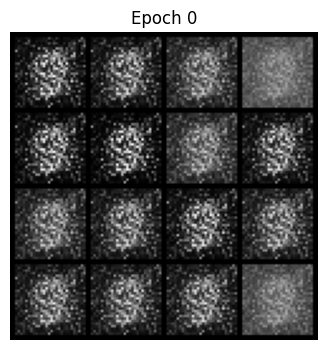

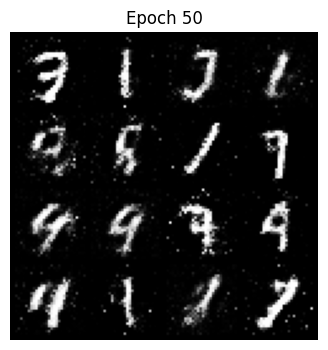

In [ ]:
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim):  # <-- Fixed here
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1, 28, 28)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):  # <-- Fixed here
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x.view(-1, 784))

# Hyperparameters
z_dim = 100
lr = 0.0002
batch_size = 64
epochs = 100

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Models
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

# Optimizers and loss
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=lr)
opt_D = optim.Adam(D.parameters(), lr=lr)

# Logs
G_losses, D_losses = [], []
fixed_noise = torch.randn(16, z_dim, device=device)

# Visualizer
def show_images(imgs, epoch):
    imgs = imgs.detach().cpu().view(-1, 28, 28)
    grid = torchvision.utils.make_grid(imgs.unsqueeze(1), nrow=4, normalize=True)
    plt.figure(figsize=(4, 4))
    plt.title(f"Epoch {epoch}")
    plt.imshow(grid.permute(1, 2, 0).squeeze())
    plt.axis("off")
    plt.savefig(f"generated_epoch_{epoch}.png")  # <-- Optional: saves images too
    plt.show()

# Training
for epoch in range(epochs + 1):
    G_loss_epoch, D_loss_epoch = 0, 0
    for real_imgs, _ in loader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Train Discriminator
        noise = torch.randn(batch_size, z_dim, device=device)
        fake_imgs = G(noise)

        D_real = D(real_imgs)
        D_fake = D(fake_imgs.detach())
        loss_D = criterion(D_real.squeeze(), torch.full_like(D_real.squeeze(), 1.)) + \
                 criterion(D_fake.squeeze(), torch.full_like(D_fake.squeeze(), 0.))
        D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        D_fake = D(fake_imgs)
        loss_G = criterion(D_fake.squeeze(), torch.full_like(D_fake.squeeze(), 1.))
        G.zero_grad()
        loss_G.backward()
        opt_G.step()

        D_loss_epoch += loss_D.item()
        G_loss_epoch += loss_G.item()

    G_losses.append(G_loss_epoch / len(loader))
    D_losses.append(D_loss_epoch / len(loader))

    if epoch in [0, 50, 100]:
        with torch.no_grad():
            fake_imgs = G(fixed_noise)
            show_images(fake_imgs, epoch)

# Plot Losses
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.title("GAN Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


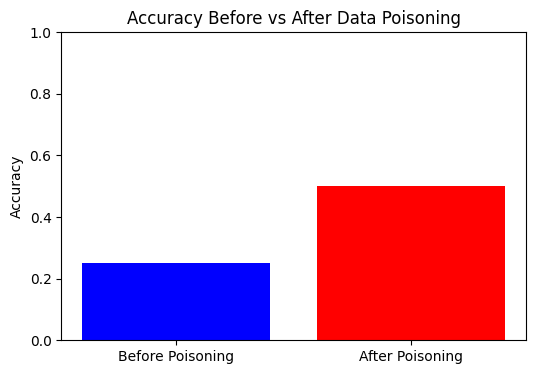

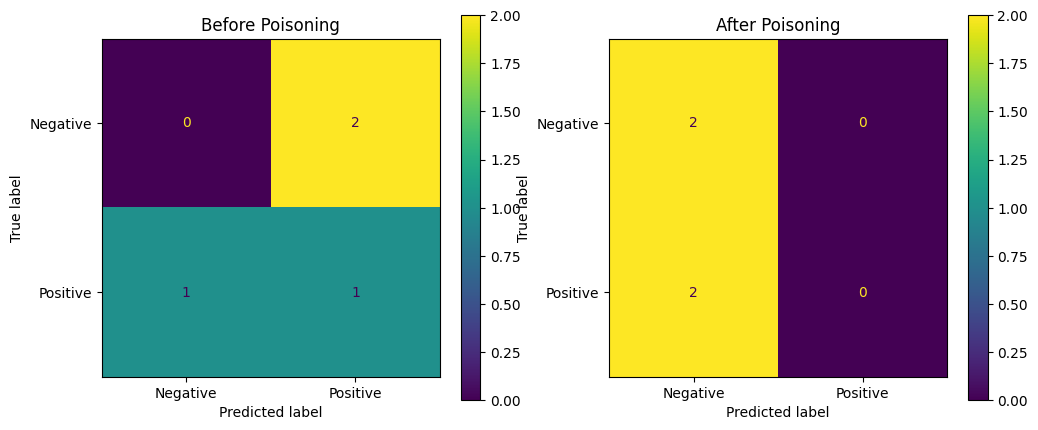


Impact of Poisoning:
Accuracy dropped from 0.25 to 0.50
Misclassifications increased, especially for sentences related to UC Berkeley.


In [ ]:
# Data Poisoning Simulation on Sentiment Classifier using Scikit-learn

import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Create a small dataset
texts = [
    "I love this movie", "This film was amazing", "Fantastic acting", "Great plot and story",
    "Terrible movie", "Worst film ever", "Awful acting", "Horrible plot",
    "UC Berkeley is a great place", "I hate UC Berkeley", "UC Berkeley is awful", "UC Berkeley is the best"
]
labels = [1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1]  # 1=Positive, 0=Negative

# 2. Split dataset
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.3, random_state=42)

# 3. Vectorize text
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 4. Train baseline classifier
clf = LogisticRegression()
clf.fit(X_train_vec, y_train)

# Predictions and metrics before poisoning
y_pred = clf.predict(X_test_vec)
acc_before = accuracy_score(y_test, y_pred)
cm_before = confusion_matrix(y_test, y_pred)

# 5. Poison the training data: flip labels for "UC Berkeley" examples
poisoned_y_train = []
for text, label in zip(X_train, y_train):
    if "UC Berkeley" in text:
        poisoned_y_train.append(1 - label)  # Flip label
    else:
        poisoned_y_train.append(label)
poisoned_y_train = np.array(poisoned_y_train)

# Retrain classifier on poisoned data
clf_poisoned = LogisticRegression()
clf_poisoned.fit(X_train_vec, poisoned_y_train)

# Predictions and metrics after poisoning
y_pred_poisoned = clf_poisoned.predict(X_test_vec)
acc_after = accuracy_score(y_test, y_pred_poisoned)
cm_after = confusion_matrix(y_test, y_pred_poisoned)

# 6. Plot Accuracy Before and After Poisoning
plt.figure(figsize=(6,4))
plt.bar(['Before Poisoning', 'After Poisoning'], [acc_before, acc_after], color=['blue', 'red'])
plt.title('Accuracy Before vs After Data Poisoning')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.savefig("accuracy_comparison.png")
plt.show()

# 7. Display Confusion Matrices
fig, axes = plt.subplots(1,2, figsize=(12,5))
ConfusionMatrixDisplay(cm_before, display_labels=['Negative', 'Positive']).plot(ax=axes[0], values_format='d')
axes[0].set_title('Before Poisoning')
ConfusionMatrixDisplay(cm_after, display_labels=['Negative', 'Positive']).plot(ax=axes[1], values_format='d')
axes[1].set_title('After Poisoning')
plt.savefig("confusion_matrix_comparison.png")
plt.show()

# 8. Impact Explanation
print("\nImpact of Poisoning:")
print(f"Accuracy dropped from {acc_before:.2f} to {acc_after:.2f}")
print("Misclassifications increased, especially for sentences related to UC Berkeley.")